<a href="https://colab.research.google.com/github/gabriel-picussa/MVP-de-CEP---Gabriel-Picussa/blob/main/C%C3%B3digo_MVP_CEP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dimensões: (1059, 8)
Colunas: ['pH', 'Temperature', 'Taste', 'Odor', 'Fat', 'Turbidity', 'Colour', 'Grade']


/tmp/ipython-input-2835973392.py:56: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors="ignore")


,pH,Temperature,Taste,Odor,Fat,Turbidity,Colour,Grade
0,3.0,40,1,1,1,1,255,low
1,3.0,40,1,0,0,0,255,low
2,3.0,40,1,1,1,1,255,low
3,3.0,40,1,1,1,1,255,low
4,3.0,40,1,0,0,0,255,low



Variável: pH
N observações: 1059


,pH
count,1059.000000
mean,6.630123
std,1.399679
min,3.000000
25%,6.500000
50%,6.700000
75%,6.800000
max,9.500000



=== pH :: I–MR (k=3.5σ) ===
X̄=6.6301 | MR̄=0.0061 | σ≈0.0054
I:  LIC=6.6111, LC=6.6301, LSC=6.6492
MR: LIC=0.0000, LC=0.0061, LSC=0.0224


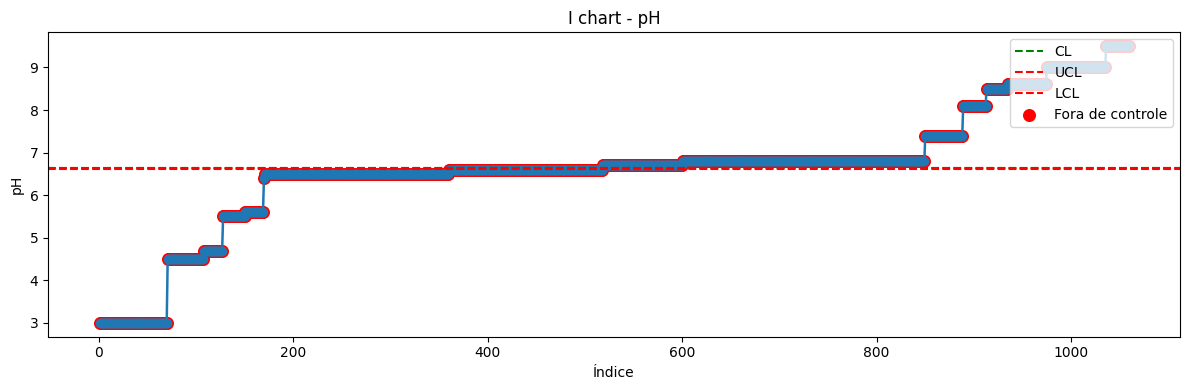

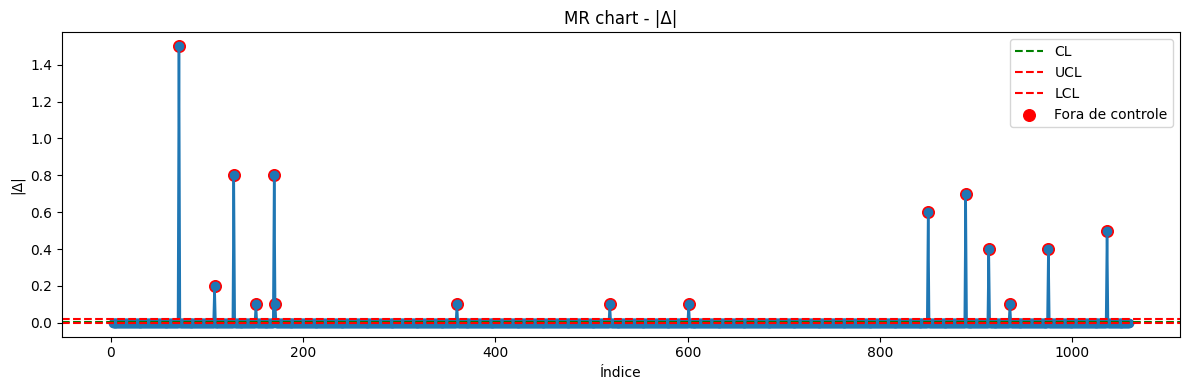


=== pH :: X̄–R rolling (n=5, step=1, k=3.5σ) ===
A2=0.577, D3=0.0, D4=2.114
X̄̄=6.7614, R̄=0.4561
X̄: LIC=6.4543, LC=6.7614, LSC=7.0685
R : LIC=0.0000, LC=0.4561, LSC=1.0490


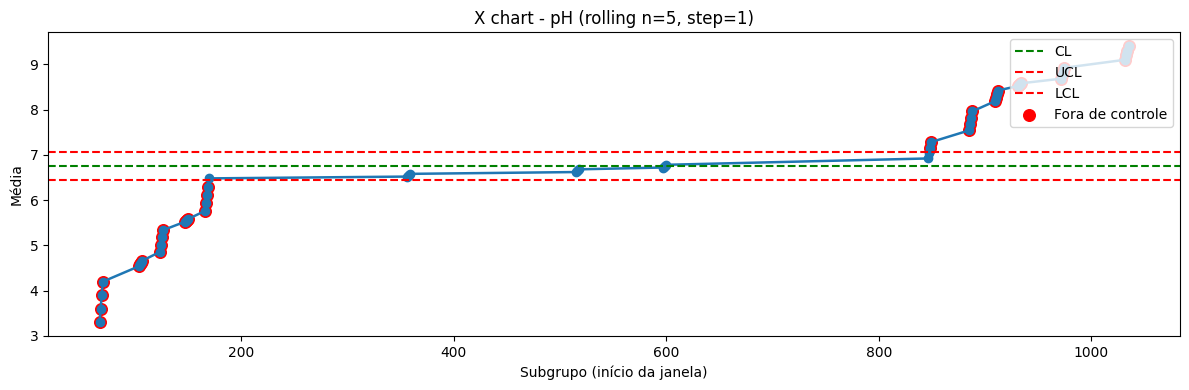

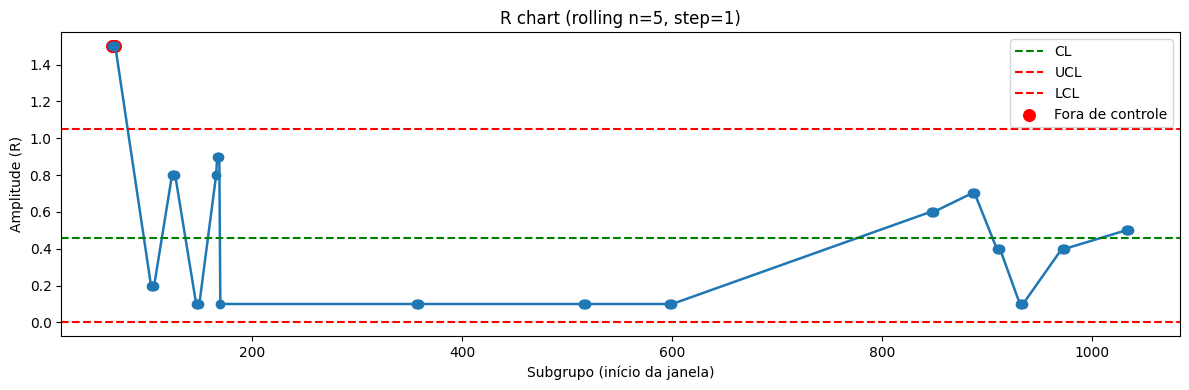


Variável: Temperature
N observações: 1059


,Temperature
count,1059.000000
mean,44.226629
std,10.098364
min,34.000000
25%,38.000000
50%,41.000000
75%,45.000000
max,90.000000



=== Temperature :: I–MR (k=3.5σ) ===
X̄=44.2266 | MR̄=0.2741 | σ≈0.2430
I:  LIC=43.3761, LC=44.2266, LSC=45.0771
MR: LIC=0.0000, LC=0.2741, LSC=0.9991


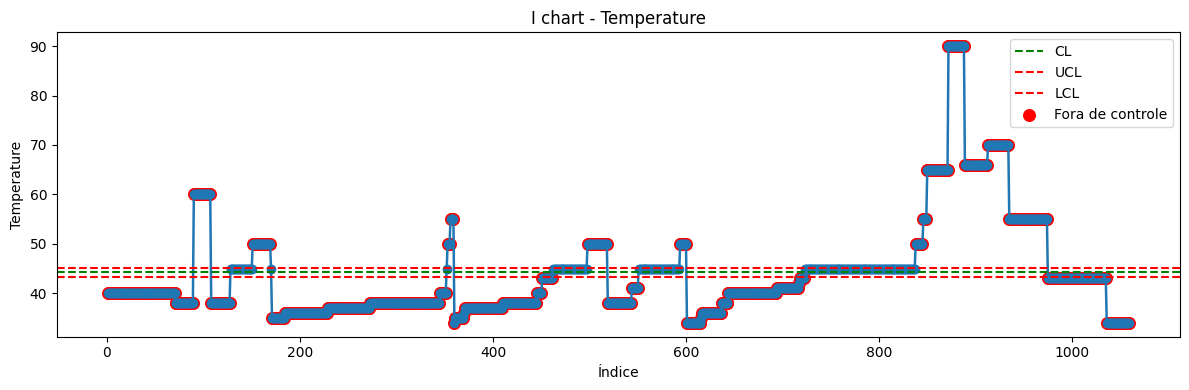

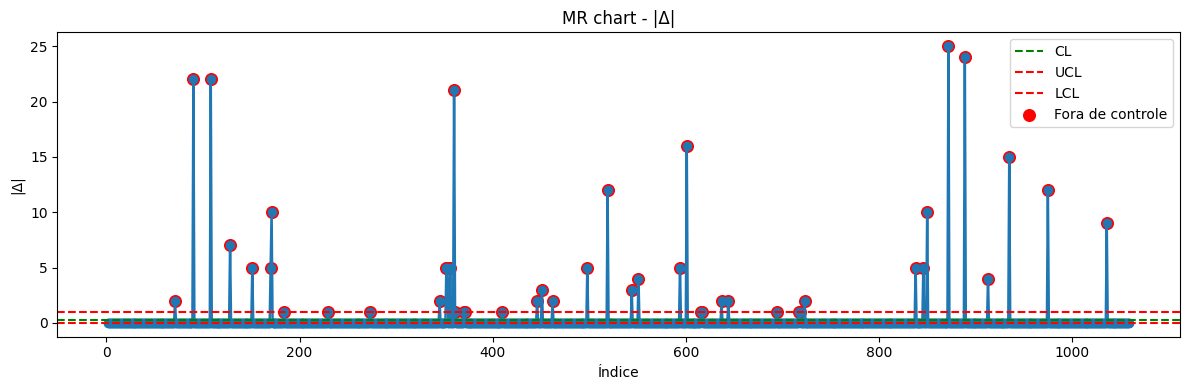


=== Temperature :: X̄–R rolling (n=5, step=1, k=3.5σ) ===
A2=0.577, D3=0.0, D4=2.114
X̄̄=45.6832, R̄=7.1863
X̄: LIC=40.8456, LC=45.6832, LSC=50.5208
R : LIC=0.0000, LC=7.1863, LSC=16.5262


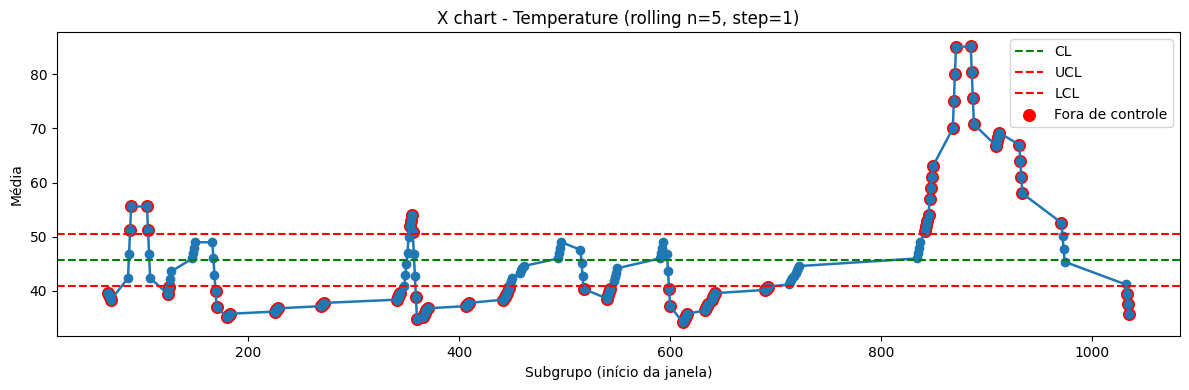

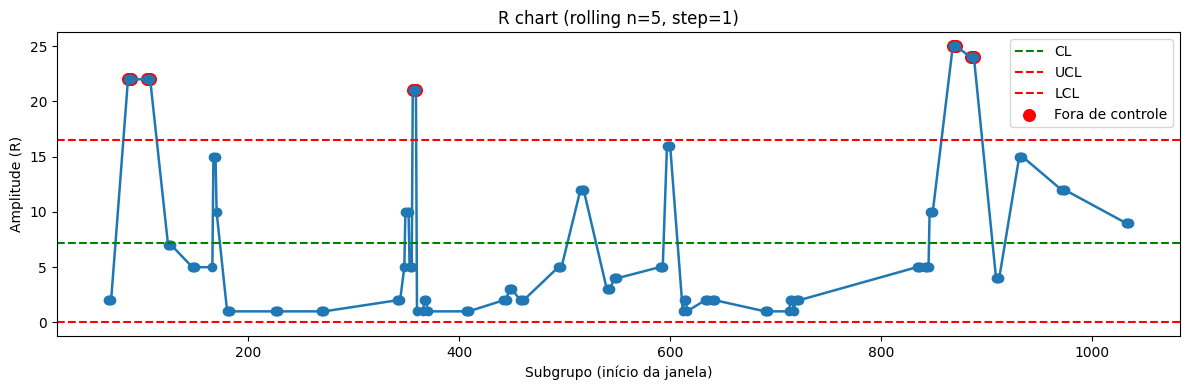


Pronto! Limites escalados para 3.5σ.
Aumente/diminua 'K_SIGMA' (ex.: 3.0, 3.5, 4.0) para controlar a quantidade de pontos fora dos limites.
Nota: abrir limites melhora a apresentação, mas reduz a sensibilidade do CEP.



In [2]:
# ============================================================
# CEP – I–MR (padrão) + X̄–R (rolling opcional, sem tempo/lote)
# Estilo: CL (verde tracejada), UCL/LCL (vermelhos tracejados), OOC em vermelho
# Com fator de abertura de limites: K_SIGMA (ex.: 3.5 ou 4.0)
# ============================================================

# --------- Config ---------
RAW_URL    = "https://raw.githubusercontent.com/gabriel-picussa/MVP-de-CEP---Gabriel-Picussa/main/milknew_organizado.xlsx"
FILE_NAME  = "milknew_organizado.xlsx"

USE_ROLLING_XBARR = True   # <- False se não quiser X̄–R (rolling)
ROLL_N            = 5      # tamanho do subgrupo (2..10)
ROLL_STEP         = 1      # passo da janela (1 = sobrepostas)
ROLL_MIN_R        = 1e-12  # descarta janelas com R≈0

# >>> AQUI: fator para "abrir" os limites (3.0 = clássico; 3.5 ou 4.0 = mais largos)
K_SIGMA           = 3.5

import os, math, requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 4)

# --------- Download e leitura ---------
def load_excel_from_raw(url, dst_path):
    try:
        r = requests.get(url, timeout=60)
        r.raise_for_status()
        with open(dst_path, "wb") as f:
            f.write(r.content)
        return dst_path
    except Exception as e:
        try:
            if "github.com" in url and "/blob/" in url:
                alt = url.replace("/blob/", "/") + "?raw=1"
            else:
                alt = url
            r = requests.get(alt, timeout=60)
            r.raise_for_status()
            with open(dst_path, "wb") as f:
                f.write(r.content)
            return dst_path
        except Exception as e2:
            raise RuntimeError(f"Falha no download: {e} | Fallback: {e2}")

path = load_excel_from_raw(RAW_URL, FILE_NAME)
df = pd.read_excel(path)

# --------- Limpeza ---------
if "Temprature" in df.columns and "Temperature" not in df.columns:
    df = df.rename(columns={"Temprature": "Temperature"})
df.columns = df.columns.str.strip()
for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors="ignore")
df = df.dropna(how="all").reset_index(drop=True)

print("Dimensões:", df.shape)
print("Colunas:", list(df.columns))
display(df.head())

# --------- Utilidades comuns ---------
def _ooc_idx(vals, lic, lsc):
    return np.where((vals < lic) | (vals > lsc))[0]

def _legend_nodup():
    h, l = plt.gca().get_legend_handles_labels()
    uniq = dict(zip(l, h))
    plt.legend(uniq.values(), uniq.keys(), loc='upper right', frameon=True)

def _scale_limits(LIC_3, LC, LSC_3, k_sigma=3.0):
    """
    Escala simetricamente os limites "3σ" para "k_sigma σ".
    Mantém o centro (LC) e multiplica a distância aos limites por (k_sigma/3).
    """
    factor = (k_sigma / 3.0)
    LIC_k = LC - factor * (LC - LIC_3)
    LSC_k = LC + factor * (LSC_3 - LC)
    return LIC_k, LC, LSC_k

def plot_series(var_name, y, LIC, LC, LSC, title, ylabel=None, x_is_subgroup=False):
    idx = np.arange(1, len(y)+1)
    fora = _ooc_idx(y, LIC, LSC)
    plt.figure()
    plt.plot(idx, y, marker='o', linewidth=1.8)
    plt.axhline(LC,  linestyle='--', color='green', label='CL')
    plt.axhline(LSC, linestyle='--', color='red',   label='UCL')
    plt.axhline(LIC, linestyle='--', color='red',   label='LCL')
    if len(fora):
        plt.scatter(idx[fora], y[fora], color='red', s=70, label='Fora de controle')
    plt.title(title)
    plt.xlabel("Subgrupo" if x_is_subgroup else "Índice")
    plt.ylabel(ylabel or var_name)
    _legend_nodup()
    plt.tight_layout()
    plt.show()

# --------- I–MR (sempre roda) ---------
def imr(y, var_name, k_sigma=K_SIGMA):
    x = y.values.astype(float)
    I  = x
    MR = np.abs(np.diff(x))

    Xbar  = I.mean()
    MRbar = MR.mean()
    d2 = 1.128
    sigma = MRbar / d2 if d2 > 0 else np.nan

    # Limites "básicos" (3σ)
    LIC_I_3, LC_I, LSC_I_3 = Xbar - 3*sigma, Xbar, Xbar + 3*sigma
    D4_3, D3_3 = 3.267, 0.0   # para MR com n=2 (3σ)
    LIC_MR_3, LC_MR, LSC_MR_3 = D3_3*MRbar, MRbar, D4_3*MRbar

    # Escala para kσ
    LIC_I, LC_I, LSC_I = _scale_limits(LIC_I_3, LC_I, LSC_I_3, k_sigma)
    LIC_MR, LC_MR, LSC_MR = _scale_limits(LIC_MR_3, LC_MR, LSC_MR_3, k_sigma)
    LIC_MR = max(0.0, LIC_MR)  # LCL de MR não pode ser < 0

    print(f"\n=== {var_name} :: I–MR (k={k_sigma}σ) ===")
    print(f"X̄={Xbar:.4f} | MR̄={MRbar:.4f} | σ≈{sigma:.4f}")
    print(f"I:  LIC={LIC_I:.4f}, LC={LC_I:.4f}, LSC={LSC_I:.4f}")
    print(f"MR: LIC={LIC_MR:.4f}, LC={LC_MR:.4f}, LSC={LSC_MR:.4f}")

    # I chart
    plot_series(var_name, I, LIC_I, LC_I, LSC_I, f"I chart - {var_name}", var_name, x_is_subgroup=False)

    # MR chart (eixo x começa no 2)
    idx = np.arange(2, len(MR)+2)
    fora = _ooc_idx(MR, LIC_MR, LSC_MR)
    plt.figure()
    plt.plot(idx, MR, marker='o', linewidth=1.8)
    plt.axhline(LC_MR,  linestyle='--', color='green', label='CL')
    plt.axhline(LSC_MR, linestyle='--', color='red',   label='UCL')
    plt.axhline(LIC_MR, linestyle='--', color='red',   label='LCL')
    if len(fora):
        plt.scatter(idx[fora], MR[fora], color='red', s=70, label='Fora de controle')
    plt.title("MR chart - |Δ|")
    plt.xlabel("Índice")
    plt.ylabel("|Δ|")
    _legend_nodup()
    plt.tight_layout()
    plt.show()

# --------- X̄–R (rolling opcional) ---------
# Constantes para X̄–R (calculadas para 3σ)
CONST = {
    2: {'A2': 1.880, 'D3': 0.000, 'D4': 3.267},
    3: {'A2': 1.023, 'D3': 0.000, 'D4': 2.574},
    4: {'A2': 0.729, 'D3': 0.000, 'D4': 2.282},
    5: {'A2': 0.577, 'D3': 0.000, 'D4': 2.114},
    6: {'A2': 0.483, 'D3': 0.000, 'D4': 2.004},
    7: {'A2': 0.419, 'D3': 0.076, 'D4': 1.924},
    8: {'A2': 0.373, 'D3': 0.136, 'D4': 1.864},
    9: {'A2': 0.337, 'D3': 0.184, 'D4': 1.816},
    10:{'A2': 0.308, 'D3': 0.223, 'D4': 1.777},
}

def rolling_subgroups(y, n=5, step=1, min_r=0.0):
    y = np.asarray(y, dtype=float)
    xbars, Rs, starts = [], [], []
    for i in range(0, len(y) - n + 1, step):
        chunk = y[i:i+n]
        r = chunk.max() - chunk.min()
        if r >= min_r:
            xbars.append(chunk.mean())
            Rs.append(r)
            starts.append(i+1)  # início da janela (1-based)
    return np.array(xbars), np.array(Rs), np.array(starts)

def limites_xbar_r_from_series(xbar, R, n):
    A2, D3, D4 = CONST[n]['A2'], CONST[n]['D3'], CONST[n]['D4']
    Xbarbar, Rbar = xbar.mean(), R.mean()
    LIC_X, LC_X, LSC_X = Xbarbar - A2*Rbar, Xbarbar, Xbarbar + A2*Rbar
    LIC_R, LC_R, LSC_R = max(0.0, D3*Rbar), Rbar, D4*Rbar
    return (LIC_X, LC_X, LSC_X), (LIC_R, LC_R, LSC_R), (Xbarbar, Rbar), (A2, D3, D4)

def plot_xbar_estilo_idx(var_name, xbar, idx, limites_k, n):
    LIC_X, LC_X, LSC_X = limites_k
    ooc = _ooc_idx(xbar, LIC_X, LSC_X)
    plt.figure()
    plt.plot(idx, xbar, marker='o', linewidth=1.8)
    plt.axhline(LC_X,  linestyle='--', color='green', label='CL')
    plt.axhline(LSC_X, linestyle='--', color='red',   label='UCL')
    plt.axhline(LIC_X, linestyle='--', color='red',   label='LCL')
    if len(ooc):
        plt.scatter(idx[ooc], xbar[ooc], color='red', s=70, label='Fora de controle')
    plt.title(f"X chart - {var_name} (rolling n={n}, step={ROLL_STEP})")
    plt.xlabel("Subgrupo (início da janela)")
    plt.ylabel("Média")
    _legend_nodup()
    plt.tight_layout()
    plt.show()

def plot_r_estilo_idx(R, idx, limites_k, n):
    LIC_R, LC_R, LSC_R = limites_k
    ooc = _ooc_idx(R, LIC_R, LSC_R)
    plt.figure()
    plt.plot(idx, R, marker='o', linewidth=1.8)
    plt.axhline(LC_R,  linestyle='--', color='green', label='CL')
    plt.axhline(LSC_R, linestyle='--', color='red',   label='UCL')
    plt.axhline(LIC_R, linestyle='--', color='red',   label='LCL')
    if len(ooc):
        plt.scatter(idx[ooc], R[ooc], color='red', s=70, label='Fora de controle')
    plt.title(f"R chart (rolling n={n}, step={ROLL_STEP})")
    plt.xlabel("Subgrupo (início da janela)")
    plt.ylabel("Amplitude (R)")
    _legend_nodup()
    plt.tight_layout()
    plt.show()

def xbar_r_rolling_pipeline(series, var_name, n=ROLL_N, step=ROLL_STEP, min_r=ROLL_MIN_R, k_sigma=K_SIGMA):
    xbar, R, idx = rolling_subgroups(series, n=n, step=step, min_r=min_r)
    if len(xbar) < 10:
        print(f"⚠️ {var_name}: poucas janelas válidas para X̄–R (obtidas {len(xbar)}).")
        return
    (limX_3), (limR_3), (centros), (consts) = limites_xbar_r_from_series(xbar, R, n)
    Xbarbar, Rbar = centros
    A2, D3, D4 = consts

    # Escala dos limites 3σ para kσ
    limX_k = _scale_limits(limX_3[0], limX_3[1], limX_3[2], k_sigma)
    limR_k = _scale_limits(limR_3[0], limR_3[1], limR_3[2], k_sigma)
    # Garante LCL_R >= 0
    limR_k = (max(0.0, limR_k[0]), limR_k[1], limR_k[2])

    print(f"\n=== {var_name} :: X̄–R rolling (n={n}, step={step}, k={k_sigma}σ) ===")
    print(f"A2={A2}, D3={D3}, D4={D4}")
    print(f"X̄̄={Xbarbar:.4f}, R̄={Rbar:.4f}")
    print(f"X̄: LIC={limX_k[0]:.4f}, LC={limX_k[1]:.4f}, LSC={limX_k[2]:.4f}")
    print(f"R : LIC={limR_k[0]:.4f}, LC={limR_k[1]:.4f}, LSC={limR_k[2]:.4f}")

    plot_xbar_estilo_idx(var_name, xbar, idx, limX_k, n)
    plot_r_estilo_idx(R, idx, limR_k, n)

# --------- Execução para pH e Temperature ---------
variaveis = [c for c in ["pH", "Temperature"] if c in df.columns]
if not variaveis:
    raise ValueError("Planilha não contém 'pH' nem 'Temperature'.")

for var in variaveis:
    print("\n" + "="*70)
    print(f"Variável: {var}")
    y = pd.to_numeric(df[var], errors="coerce").dropna().astype(float).reset_index(drop=True)
    print("N observações:", len(y))
    display(y.describe())

    # I–MR (com K_SIGMA)
    imr(y, var, k_sigma=K_SIGMA)

    # X̄–R (rolling) opcional com K_SIGMA
    if USE_ROLLING_XBARR:
        xbar_r_rolling_pipeline(y, var, n=ROLL_N, step=ROLL_STEP, min_r=ROLL_MIN_R, k_sigma=K_SIGMA)

print(f"""
Pronto! Limites escalados para {K_SIGMA}σ.
Aumente/diminua 'K_SIGMA' (ex.: 3.0, 3.5, 4.0) para controlar a quantidade de pontos fora dos limites.
Nota: abrir limites melhora a apresentação, mas reduz a sensibilidade do CEP.
""")
